# **Import Lib**

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

# **Data Load**

In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishkumardatalab/medical-insurance-price-prediction")

print("Path to dataset files:", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'medical-insurance-price-prediction' dataset.
Path to dataset files: /kaggle/input/medical-insurance-price-prediction


In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [23]:
df.replace('?', np.nan, inplace=True)

df['sex'] = df['sex'].map({'female': 0, 'male': 1})

df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

df['region'] = df['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})

df['bmi'] = df['bmi'].astype(float)

df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520
5,31,0,25.740,0,0,1,3756.62160
6,46,0,33.440,1,0,1,8240.58960
7,37,0,27.740,3,0,2,7281.50560
8,37,1,29.830,2,0,3,6406.41070
9,60,0,25.840,0,0,2,28923.13692


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   int64  
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   int64  
 5   region    2772 non-null   int64  
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


# **Exploratory Data Analysis**

(0.0, 66902.8557155)

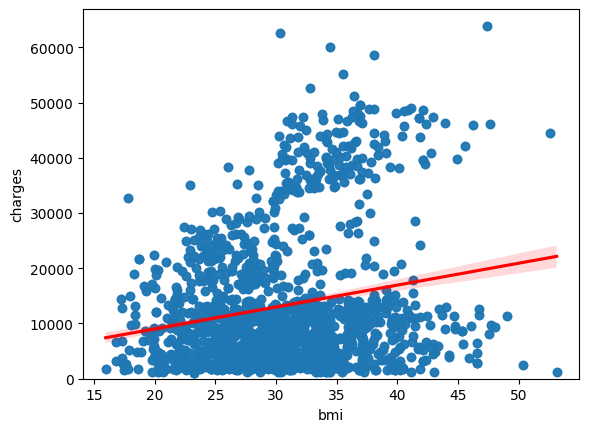

In [25]:
sns.regplot(x='bmi', y='charges', data=df, line_kws={"color": "red"})
plt.ylim(0,)

Melalui visualisasi regplot, kita dapat mengidentifikasi adanya korelasi positif antara Body Mass Index (BMI) dan biaya asuransi (charges). Garis tren yang menanjak mengindikasikan bahwa peningkatan BMI umumnya diikuti dengan kenaikan biaya medis. Meski demikian, sebaran titik data yang cukup lebar menunjukkan bahwa BMI bukanlah satu-satunya variabel penentu, mengisyaratkan adanya interaksi dengan faktor lain seperti status merokok.

<Axes: xlabel='smoker', ylabel='charges'>

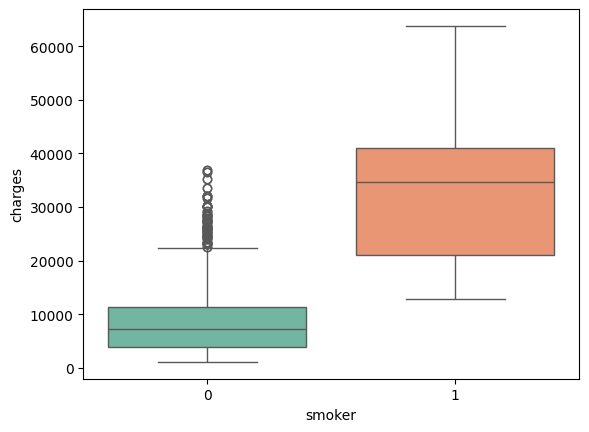

In [26]:
sns.boxplot(x='smoker', y='charges', data=df, hue='smoker', palette='Set2', legend=False)

Penggunaan boxplot dengan jelas memperlihatkan perbedaan distribusi biaya asuransi yang sangat kontras antara kelompok perokok dan non-perokok. Nilai median tagihan kelompok perokok berada di posisi yang jauh lebih tinggi. Menariknya, nilai minimum dari batas kotak perokok bahkan hampir menyentuh batas atas (outliers) dari kelompok non-perokok. Hal ini mengonfirmasi secara visual bahwa status merokok adalah faktor risiko terkuat yang menyebabkan lonjakan biaya asuransi secara signifikan

In [27]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.000932,0.298624
sex,-0.026046,1.000000,0.042924,0.016020,0.082326,-0.004808,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,-0.159178,0.199846
children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.016111,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.006751,0.788783
region,-0.000932,-0.004808,-0.159178,-0.016111,0.006751,1.000000,0.013530
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.013530,1.000000


# **Model Development**

In [28]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

In [29]:
X = df[['smoker']]
Y = df[['charges']]
lm.fit(X,Y);

In [30]:
lm.score(X,Y)

0.6221791718835359

In [31]:
Z = df[['smoker', 'bmi', 'sex', 'age', 'children', 'region']]
lm.fit(Z,Y);

In [32]:
lm.score(Z,Y)

0.7507632141014774

In [33]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print(r2_score(Y,ypipe))

0.846346155794701


# **Model Evaluation and Refinement**

In [34]:
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)

ridge=Ridge(alpha=0.1)
ridge.fit(x_train,y_train)
ridge.score(x_test,y_test)

0.6776458828144427

In [35]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
ridge.fit(x_train_pr, y_train)
y_hat = ridge.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.786533867487368
